# Step 0: Setup and imports

In [7]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

!pip install solas-ai -q
import solas_disparity as sd


# Load and clean COMPAS data (Lecture 01 pipeline)
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

df = raw_data[["age", "c_charge_degree", "race", "age_cat", "score_text", "sex", "priors_count", "days_b_screening_arrest", "decile_score", "is_recid", "two_year_recid", "c_jail_in", "c_jail_out"
]]

df = df[df["days_b_screening_arrest"] <= 30]
df = df[df["days_b_screening_arrest"] >= -30]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]

# Create 'high_risk' column
df['high_risk'] = (df['decile_score'] >= 7).astype(int)

print(f"N = {len(df):,}")
print(df[['race','sex','high_risk','two_year_recid']].head())

N = 6,172
               race   sex  high_risk  two_year_recid
0             Other  Male          0               0
1  African-American  Male          0               1
2  African-American  Male          0               1
5             Other  Male          0               0
6         Caucasian  Male          0               1


This step loaded in the necessary Python packages and the raw data, and filtered out rows that should not be included for analysis. Once again we are working with 6,172 records - the expected amount.

# Step 1: AIR and Marginal Effect by race

**How often does each racial group get labeled “high risk”?**

In [ ]:
from pathlib import Path
from warnings import simplefilter
simplefilter("ignore")

### Prepare data for solas_ai

In [8]:
# Encode race categories as binary
race_dummies = pd.get_dummies(df['race'], prefix='is').astype(int)

# Attach these indicators to original dataframe
df = pd.concat([df, race_dummies], axis=1)

print("df with Racial Indicators:")
df[['race'] + race_dummies.columns.tolist()].head(10)

df with Racial Indicators:


,race,is_African-American,is_Asian,is_Caucasian,is_Hispanic,is_Native American,is_Other
0,Other,0,0,0,0,0,1
1,African-American,1,0,0,0,0,0
2,African-American,1,0,0,0,0,0
5,Other,0,0,0,0,0,1
6,Caucasian,0,0,1,0,0,0
7,Other,0,0,0,0,0,1
8,Caucasian,0,0,1,0,0,0
10,Caucasian,0,0,1,0,0,0
11,African-American,1,0,0,0,0,0
12,Caucasian,0,0,1,0,0,0


In [9]:
protected_groups = ["is_African-American", "is_Asian", "is_Native American", "is_Hispanic", "is_Other"]
reference_groups = ["is_Caucasian", "is_Caucasian", "is_Caucasian", "is_Caucasian", "is_Caucasian"]
group_categories = ["race", "race", "race", "race", "race"]

print(f"protected groups: {protected_groups}")
print(f"reference groups: {reference_groups}")
print(f"group categories: {group_categories}")

protected groups: ['is_African-American', 'is_Asian', 'is_Native American', 'is_Hispanic', 'is_Other']
reference groups: ['is_Caucasian', 'is_Caucasian', 'is_Caucasian', 'is_Caucasian', 'is_Caucasian']
group categories: ['race', 'race', 'race', 'race', 'race']


### AIR on Race using solas_ai

In [15]:
from IPython.display import display

# Switch high_risk so that Favorable (Not High Risk) = 1
favorable = (df["high_risk"] == 0).astype(int)

air = sd.adverse_impact_ratio(
    group_data=df,
    protected_groups=protected_groups,
    reference_groups=reference_groups,
    group_categories=group_categories,
    outcome=favorable,
    sample_weight=None,
    air_threshold=0.80,
    percent_difference_threshold=0,
)
display(air.summary_table)

,Reference Group,Group Category,Observations,Percent Missing,Total,Favorable,Percent Favorable,Percent Difference Favorable,AIR,P-Values,Practically Significant,Shortfall
Group,,,,,,,,,,,,
is_African-American,is_Caucasian,race,6172,0.0,3175,1987,0.625827,0.214401,0.744829,2.598543e-63,Yes,680.724679
is_Asian,is_Caucasian,race,6172,0.0,31,27,0.870968,-0.030739,1.036585,8.071686e-01,No,NaN
is_Native American,is_Caucasian,race,6172,0.0,11,5,0.454545,0.385683,0.540979,3.847356e-03,Yes,4.242511
is_Hispanic,is_Caucasian,race,6172,0.0,509,434,0.852652,-0.012424,1.014786,5.415250e-01,No,NaN
is_Other,is_Caucasian,race,6172,0.0,343,312,0.909621,-0.069393,1.082588,5.857760e-04,No,NaN
is_Caucasian,,race,6172,0.0,2103,1767,0.840228,NaN,NaN,NaN,,NaN


This table shows that rate at which each subgroup has a favorable outcome. "Favorable" indicates the number of defendants in the subgroup who are *not* labeled high-risk.

AIR compares each group's favorable rate to the Caucasian group. An AIR output less than 0.80 indicates potential adverse impact. Several groups fall below that threshold; they receive favorable outcomes far less frequently than Caucasian defendants.

### ME on Race (unavailable with solas_ai)

In [32]:
def selection_rate(df, group_col, outcome_col, ref_group):
    """Selection rates, AIR, and ME relative to reference group"""
    # Calculate mean outcome (selection rate) for each group
    rates = df.groupby(group_col)[outcome_col].mean().rename('selection_rate').to_frame()

    # Get the rate for the reference group
    ref_rate = rates.loc[ref_group, 'selection_rate']

    # Calculate AIR and Marginal Effect (ME)
    rates['AIR'] = rates['selection_rate'] / ref_rate
    rates['ME'] = rates['selection_rate'] - ref_rate
    rates['flag_80'] = rates['AIR'].apply(lambda x: '*** BELOW 0.80' if x < 0.80 else '')

    return rates.reset_index()

sir = selection_rate(df, 'race', 'high_risk', ref_group='Caucasian')
print(sir.sort_values('AIR').to_string(index=False))

            race  selection_rate      AIR        ME        flag_80
           Other        0.090379 0.565676 -0.069393 *** BELOW 0.80
           Asian        0.129032 0.807604 -0.030739               
        Hispanic        0.147348 0.922239 -0.012424               
       Caucasian        0.159772 1.000000  0.000000               
African-American        0.374173 2.341924  0.214401               
 Native American        0.545455 3.413961  0.385683               


Marginal Effect (ME) shows the raw percentage point difference for each subgroup.
African-American defendants are labeled high-risk 21.4%  more often than Caucasian defendants.
Native American defendants are labeled high-risk 38.5%  more often than Caucasian defendants.

### SMD on Race using solas_ai

In [26]:
smd = sd.standardized_mean_difference(
    group_data=df,
    protected_groups=protected_groups,
    reference_groups=reference_groups,
    group_categories=group_categories,
    outcome=df["decile_score"],
    smd_threshold=30,
    lower_score_favorable=True
)
smd.summary_table

,Reference Group,Group Category,Observations,Percent Missing,Total,Average Outcome,Difference in Average Outcome,Std. Dev. of Outcomes,SMD,P-Values,Practically Significant
Group,,,,,,,,,,,
is_Female,is_Male,sex,6172,0.0,1175,4.063830,-0.438071,2.839463,-15.427963,0.000002,No
is_Male,,sex,6172,0.0,4997,4.501901,NaN,2.839463,NaN,NaN,


This table shows average COMPAS scores for each subgroup. Higher scores indicate COMPAS finds the defendant more likely to reoffend.

A negative SMD means that the COMPAS scores for defendants in that group are, on average, lower than the average COMPAS score of Caucasian defendants.
A positive SMD means that the COMPAS scores for defendants in that group are, on average, higher than the average COMPAS score of Caucasian defendants.

African-American and Native American defendants have noticeably higher average scores than Caucasian defendants.


In [17]:
# prepare data with gender categories encoded as binary
race_dummies = pd.get_dummies(df['sex'], prefix='is').astype(int)

df = pd.concat([df, race_dummies], axis=1)

print("df with gender indicators:")
display(df[['sex'] + race_dummies.columns.tolist()].head(10))

df with Gender Indicators:


,sex,is_Female,is_Male
0,Male,0,1
1,Male,0,1
2,Male,0,1
5,Male,0,1
6,Male,0,1
7,Male,0,1
8,Female,1,0
10,Male,0,1
11,Male,0,1
12,Female,1,0


In [18]:
protected_groups = ["is_Female"]
reference_groups = ["is_Male"]
group_categories = ["sex"]

print(f"protected groups: {protected_groups}")
print(f"reference groups: {reference_groups}")
print(f"group categories: {group_categories}")

protected groups: ['is_Female']
reference groups: ['is_Male']
group categories: ['sex']


### AIR on Gender using solas_ai

In [19]:
air = sd.adverse_impact_ratio(
    group_data=df,
    protected_groups=protected_groups,
    reference_groups=reference_groups,
    group_categories=group_categories,
    outcome=favorable,
    sample_weight=None,
    air_threshold=0.80,
    percent_difference_threshold=0,
)
air.summary_table

,Reference Group,Group Category,Observations,Percent Missing,Total,Favorable,Percent Favorable,Percent Difference Favorable,AIR,P-Values,Practically Significant,Shortfall
Group,,,,,,,,,,,,
is_Female,is_Male,sex,6172,0.0,1175,940,0.800000,-0.081169,1.112918,1.791485e-08,No,NaN
is_Male,,sex,6172,0.0,4997,3592,0.718831,NaN,NaN,NaN,,NaN


This table compares favorable outcomes between men and women. Again, "Favorable" indicates the number of defendants in the subgroup who are *not* labeled high-risk.

Women receive favorable outcomes slightly more often than men. The AIR is above 0.80, meaning there is no evidence of adverse impact against women in this comparison.

### ME on Gender (unavailable with solas_ai)

In [31]:
def selection_rate(df, group_col, outcome_col, ref_group):
    """Selection rates, AIR, and ME relative to reference group"""
    # Calculate mean outcome (selection rate) for each group
    rates = df.groupby(group_col)[outcome_col].mean().rename('selection_rate').to_frame()

    # Get the rate for the reference group
    ref_rate = rates.loc[ref_group, 'selection_rate']

    # Calculate AIR and Marginal Effect (ME)
    rates['AIR'] = rates['selection_rate'] / ref_rate
    rates['ME'] = rates['selection_rate'] - ref_rate
    rates['flag_80'] = rates['AIR'].apply(lambda x: '*** BELOW 0.80' if x < 0.80 else '')

    return rates.reset_index()

# Switching analysis from 'race' to 'sex' using 'Male' as the reference group
sir = selection_rate(df, 'sex', 'high_risk', ref_group='Male')
print(sir.sort_values('AIR').to_string(index=False))

   sex  selection_rate      AIR        ME        flag_80
Female        0.200000 0.711317 -0.081169 *** BELOW 0.80
  Male        0.281169 1.000000  0.000000               


Female defendants are labeled high-risk 8.1%  less often than Male defendants. This is under 80% and does not suggest potential adverse effects.

### SMD on Gender using solas_ai

In [20]:
smd = sd.standardized_mean_difference(
    group_data=df,
    protected_groups=protected_groups,
    reference_groups=reference_groups,
    group_categories=group_categories,
    outcome=df["decile_score"],
    smd_threshold=30,
    lower_score_favorable=True
)
smd.summary_table

,Reference Group,Group Category,Observations,Percent Missing,Total,Average Outcome,Difference in Average Outcome,Std. Dev. of Outcomes,SMD,P-Values,Practically Significant
Group,,,,,,,,,,,
is_Female,is_Male,sex,6172,0.0,1175,4.063830,-0.438071,2.839463,-15.427963,0.000002,No
is_Male,,sex,6172,0.0,4997,4.501901,NaN,2.839463,NaN,NaN,


Female defendants have noticeably lower average scores than Male defendants.

In [21]:
# Two-proportion z-test: Black vs. White
groups = ['African-American', 'Caucasian']
ns = df[df['race'].isin(groups)].groupby('race')['high_risk'].count()
events = df[df['race'].isin(groups)].groupby('race')['high_risk'].sum()
stat, pval = proportions_ztest(events[groups].values, ns[groups].values)
print(f"\nAIR test: z = {stat:.3f}, p = {pval:.4f}")


AIR test: z = 16.827, p = 0.0000


The two-proportion z-test indicates that the difference in the rates that African-American defendants and Caucasian defendants are labeled high-risk is *statistically significant* and not due to random chance.

# Step 2: Error-Rate Disparity Analysis

**When COMPAS is wrong, who is it wrong about?**

In [22]:
# FPR and FNR by race
def error_rates(df, group_col, pred_col, outcome_col):
  results = []
  for grp, g in df.groupby(group_col):
    tp = ((g[pred_col]==1) & (g[outcome_col]==1)).sum()
    tn = ((g[pred_col]==0) & (g[outcome_col]==0)).sum()
    fp = ((g[pred_col]==1) & (g[outcome_col]==0)).sum()
    fn = ((g[pred_col]==0) & (g[outcome_col]==1)).sum()
    results.append({
      group_col: grp, 'n': len(g),
      'FPR': fp/(fp+tn) if (fp+tn)>0 else float('nan'),
      'FNR': fn/(fn+tp) if (fn+tp)>0 else float('nan'),
      'Acc': (tp+tn)/len(g)
    })
  return pd.DataFrame(results)
er = error_rates(df, 'race', 'high_risk', 'two_year_recid')
print(er.sort_values('FPR', ascending=False).to_string(index=False))
# Highlight Black vs. White disparity
for grp in ['African-American', 'Caucasian']:
  row = er.loc[er['race'] == grp]
  print(f"  {grp}: FPR={row['FPR'].values[0]:.3f} ", f"FNR={row['FNR'].values[0]:.3f}")

            race    n      FPR      FNR      Acc
 Native American   11 0.333333 0.200000 0.727273
African-American 3175 0.227873 0.492474 0.633701
        Hispanic  509 0.106250 0.783069 0.642436
       Caucasian 2103 0.082748 0.720195 0.668093
           Asian   31 0.043478 0.625000 0.806452
           Other  343 0.031963 0.806452 0.688047
  African-American: FPR=0.228  FNR=0.492
  Caucasian: FPR=0.083  FNR=0.720


This output examines two types of errors, broken down by the defendant's race: </br>
> **false positive (FPR)**</br> defendants who were labeled *high-risk* and `did not` reoffend in the monitoring period</br>
> **false negative (FNR)**</br> defendants who were labeled *low-risk* and *did*  reoffend in the monitoring period</br>

The output also indicates the accuracy rate of the model for each group. </br> </br>
For the **FPR**, African-American defendants have a false positive rate almost three times that of Caucasian defendants - they were incorrectly labeled high-risk *far* more often. For the **FNR**, African-American defendants have a false negative rate of 0.492 compared to Caucasian defendants' false negative rate of 0.72 - they are *far* less likely to be incorrectly labeled low-risk.</br>

These error rates indicate COMPAS misses Caucasian reoffenders more often, and incorrectly predicts more African-American defendants will reoffend. The accuracy rates affirm this disparity: the accuracy rate for Caucasian defendants is 67%, but for African-American defendants that same rate is 63%.

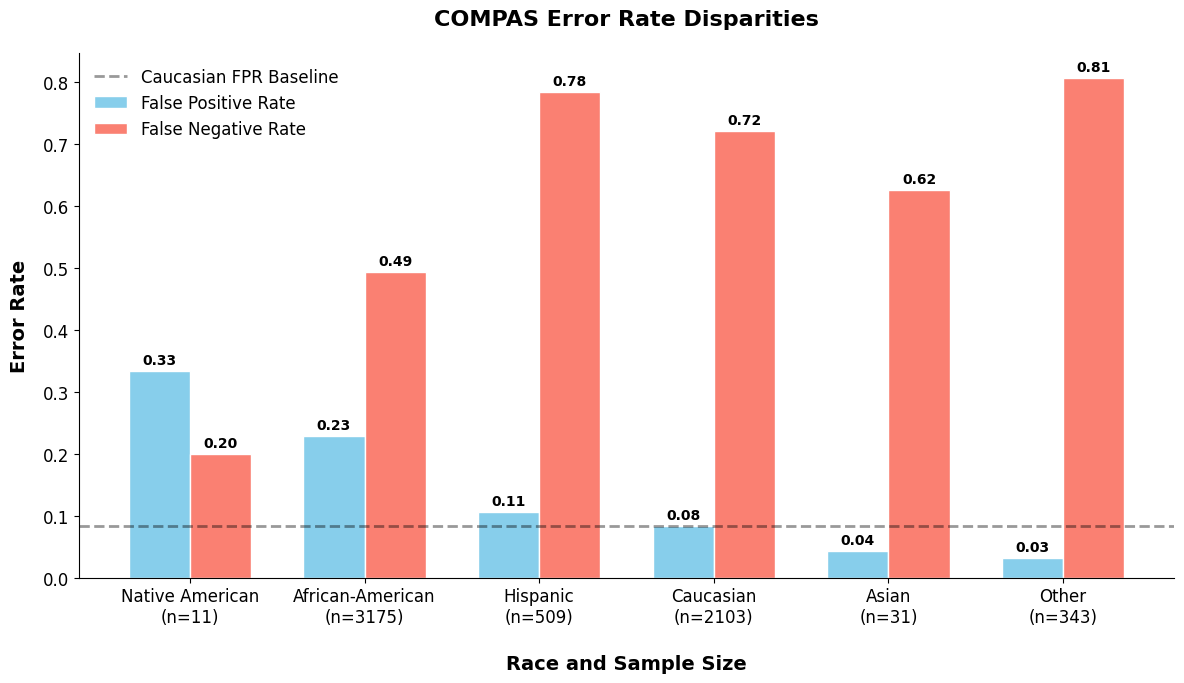

In [23]:
# grouped bar chart of FPR and FNR by race
import matplotlib.pyplot as plt
import numpy as np

# Set style parameters
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 16, 'axes.labelsize': 14})

# Prepare data and add sample sizes to labels
plot_df = er.sort_values('FPR', ascending=False).copy()
plot_df['label'] = plot_df.apply(lambda r: f"{r['race']}\n(n={int(r['n'])})", axis=1)

x = np.arange(len(plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

# Plot bars
rects1 = ax.bar(x - width/2, plot_df['FPR'], width,
                label='False Positive Rate', color='skyblue',
                edgecolor='white')
rects2 = ax.bar(x + width/2, plot_df['FNR'], width,
                label='False Negative Rate', color='salmon',
                edgecolor='white')

# Add labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

# Labels and titles
ax.set_ylabel('Error Rate', fontweight='bold', labelpad=10)
ax.set_xlabel('Race and Sample Size', fontweight='bold', labelpad=20)
ax.set_title('COMPAS Error Rate Disparities', fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(plot_df['label'])

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Reference line for Caucasian FPR
cauc_fpr = plot_df.loc[plot_df['race'] == 'Caucasian', 'FPR'].values[0]
ax.axhline(cauc_fpr, color='black', linestyle='--', linewidth=2, alpha=0.4, label='Caucasian FPR Baseline')

# Legend refinement
ax.legend(frameon=False, loc='upper left')

plt.tight_layout()
plt.show()

# Step 3: Standardized Mean Difference

**What is the average COMPAS score for each racial group, compared to the White group?**

In [24]:
# Step 3: SMD calculation using binary indicator columns
prot_cols = ['is_African-American', 'is_Asian', 'is_Hispanic', 'is_Native American', 'is_Other']
ref_cols = ['is_Caucasian'] * len(prot_cols)

smd_result = sd.standardized_mean_difference(
    group_data=df[prot_cols + ['is_Caucasian']],
    protected_groups=prot_cols,
    reference_groups=ref_cols,
    group_categories=['race'] * len(prot_cols),
    outcome=df['decile_score'],
    smd_threshold=0.2
)

print("Standardized Mean Difference (Race):")
print(smd_result)

Standardized Mean Difference (Race):
+-----------------------+--------------------------------------------------------------------------+
|   Protected Groups    | is_African-American, is_Asian, is_Hispanic, is_Native American, is_Other |
|   Reference Groups    |   is_Caucasian, is_Caucasian, is_Caucasian, is_Caucasian, is_Caucasian   |
|   Group Categories    |                       race, race, race, race, race                       |
|     SMD Threshold     |                                   0.2                                    |
|    SMD Denominator    |                                population                                |
| Lower Score Favorable |                                   True                                   |
|    Affected Groups    |                 is_African-American, is_Native American                  |
|  Affected Reference   |                        is_Caucasian, is_Caucasian                        |
|  Affected Categories  |                             

A negative SMD means that the COMPAS scores for defendants in that group are lower than the the COMPAS scores of Caucasian defendants. As we saw in the bar graph, Native Americans and African-Americans have mean scores higher than Caucasians, with the differences being categorized as "very large" and "large", respectively.

# Step 4: Intersectional Subgroup Analysis
**Which combined race–sex groups are most disadvantaged?**

In [25]:
# Intersectional analysis -- race x sex
df['subgroup'] = df['race'] + ' / ' + df['sex']
# Keep subgroups with n >= 30
counts = df['subgroup'].value_counts()
valid_sg = counts[counts >= 30].index
df_sub = df[df['subgroup'].isin(valid_sg)].copy()
sub_rates = (df_sub.groupby('subgroup')['high_risk'].agg(['mean','count']).rename(columns={'mean':'selection_rate','count':'n'}).reset_index())
ref_rate = sub_rates.loc[sub_rates['subgroup']=='Caucasian / Male','selection_rate'].values[0]
sub_rates['AIR'] = sub_rates['selection_rate'] / ref_rate
sub_rates['flag'] = sub_rates['AIR'].apply(lambda x: '*** BELOW 0.80' if x < 0.80 else '')
print(sub_rates.sort_values('AIR').to_string(index=False))
worst = sub_rates.loc[sub_rates['AIR'].idxmin()]
print(f"\nWorst: {worst['subgroup']}, AIR={worst['AIR']:.3f} and "
f"n={worst['n']}")

                 subgroup  selection_rate    n      AIR           flag
        Hispanic / Female        0.024390   82 0.153839 *** BELOW 0.80
           Other / Female        0.068966   58 0.434993 *** BELOW 0.80
             Other / Male        0.094737  285 0.597542 *** BELOW 0.80
         Caucasian / Male        0.158544 1621 1.000000               
       Caucasian / Female        0.163900  482 1.033784               
          Hispanic / Male        0.170960  427 1.078313               
African-American / Female        0.269581  549 1.700354               
  African-American / Male        0.396040 2626 2.497977               

Worst: Hispanic / Female, AIR=0.154 and n=82


The model creates sub-groups combining each defendant's race and sex, then calculates the hig-risk rate of each subgroup and their AIR, using Caucasian males as the reference group.

The biggest differences are with two groups:</br>
>**Hispanic females**</br>
An AIR below 0.8 indicates potential adverse impact; the AIR for this group is only 0.154!  
>**African-American males**</br>
This group's AIR is 2.498; they are labeled high-risk at a rate of nearly 2.5 times higher than Caucasian males.

This step spotlights the concept that fairness issues can be even more extreme when overlapping identities are combined for smaller sub-groups. Disparities for larger groups may obscure the more dramatic rates seen in more specific subgroups.